### Fitting Emission-in-Absorption Lines

In this tutorial, we will fit the H$\beta$ emission line emerging from a *continuum dip*. This type of feature is commonly observed in the spectra of star-forming galaxies and is typically interpreted as Balmer absorption produced by A- and F-type stars. 

Its presence indicates that the continuum is dominated by the stellar light of the host galaxy, specifically by a relatively young stellar population (with ages of a few hundred million years) that still exhibits strong absorption features.

We begin by importing the `analysis()` class from **easyspec**:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from easyspec.analysis import analysis
analysis = analysis()

easyspec-cleaning version:  1.0.0
easyspec-extraction version:  1.0.2


Let's load our data:

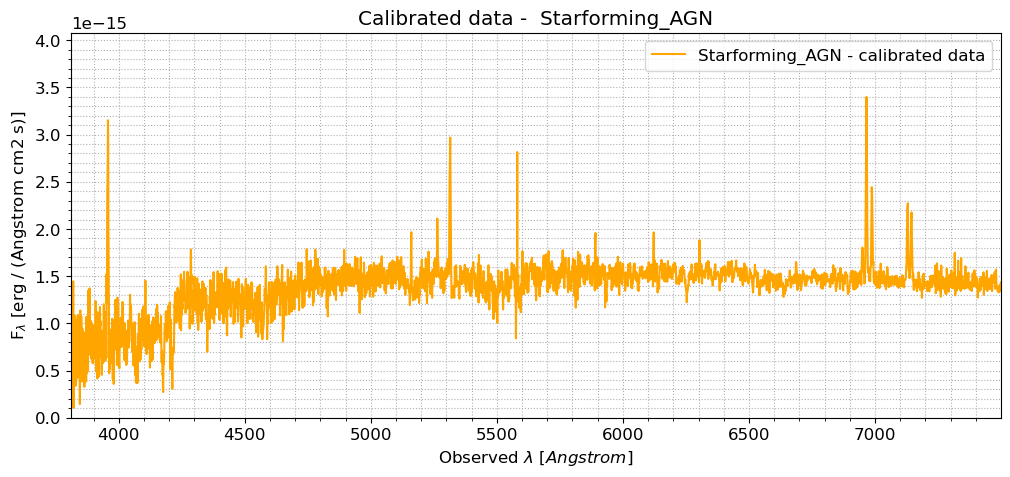

In [2]:
wavelengths, flux_density = analysis.load_calibrated_data("./spec_emission_in_abs.dat",
                                          target_name="Starforming_AGN", output_dir = "./results", plot = True)

## Finding the Lines

For a detailed explanation of how the function `analysis.find_lines()` works, refer to [this tutorial](https://github.com/ranieremenezes/easyspec/blob/main/tutorial/spectral_analysis_easyspec.ipynb).

In this guide, we will focus exclusively on the H$\beta$ line. **The most critical step is to accurately model the continuum in the vicinity of the target line**:

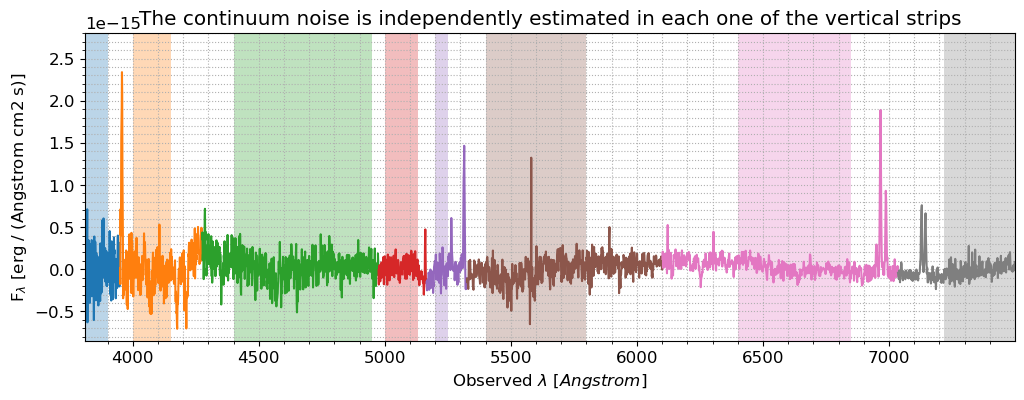

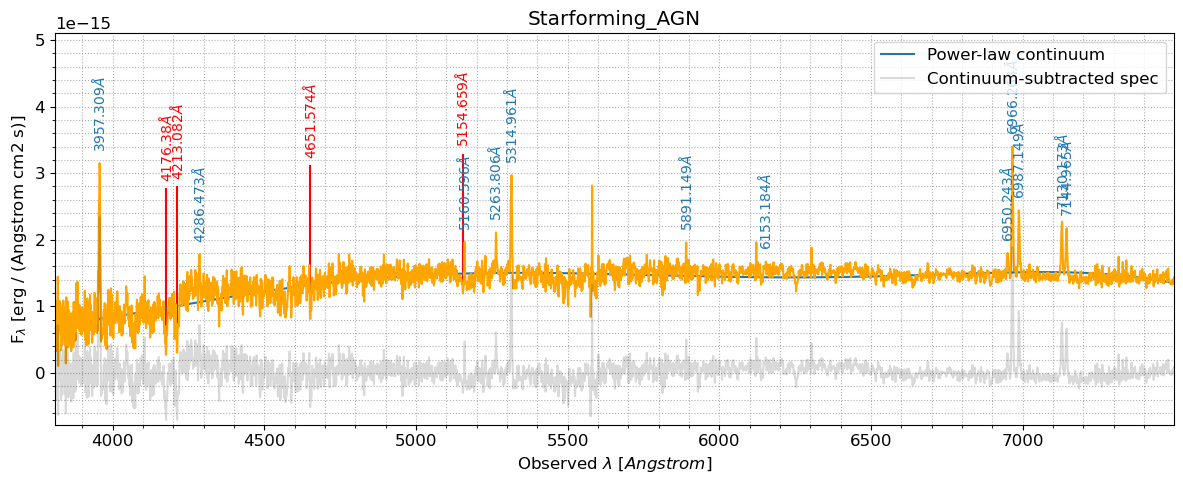

In [3]:
continuum_regions = [[3500,3900],[4000,4150],[4400,4950],[5000,5130],[5200,5250],[5400,5800],[6400,6850],[7220,7700]]
continuum_baseline, line_std_deviation, wavelength_peak_positions, peak_heights, line_significance = analysis.find_lines(wavelengths, flux_density,
                    line_significance_sigma = 3.1, peak_distance = 5,
                    peak_width = 2, method="pl", continuum_regions=continuum_regions, pl_order=5,
                    smooth_window=55,plot_lines = True, plot_regions = True, save_plot = True)

We can adjust the parameters `line_significance_sigma`, `peak_distance`, and `peak_width` to ensure that all relevant spectral lines are properly detected.

In this particular case, **easyspec** successfully identifies both the emission and absorption components of the H$\beta$ line. However, this is not always guaranteed: depending on the data quality, you may need to manually add one of the components, as demonstrated below.

The variable `wavelength_peak_positions` stores the positions of all detected lines. Since our focus is on H$\beta$, we will consider only components 5 and 6:

In [4]:
wavelength_peak_positions_slice = wavelength_peak_positions[[5,6]]
rest_frame_line_wavelengths = [4861,4861]
line_names = ["Hbeta","Hbeta_abs"]
peak_heights_slice = peak_heights[[5,6]]
line_std_deviation_slice = line_std_deviation[[5,6]]
which_models= "Lorentzian" 
overplot_archival_lines = ["H","He","O","Ne","C","Si","N","S"]

Note that both components share the same rest-frame wavelength.

We can now set `priors = None` (i.e., use automatic priors) and proceed to run the MCMC:

In [5]:
priors = None

Running burn-in...


100%|████████████████████████████████████████| 100/100 [00:00<00:00, 247.90it/s]


Running production...


100%|████████████████████████████████████████| 200/200 [00:00<00:00, 263.71it/s]


Single-core processing took 1.2 seconds


Archival lines are taken from NIST Atomic Spectra database: https://www.nist.gov/pml/atomic-spectra-database
We adopt vacuum wavelengths for lines with wavelengths < 2000 Angstroms and air wavelengths for lines with wavelengths > 2000 Angstroms.
If you use these lines in your research, please cite the NIST Atomic Spectra database appropriately.


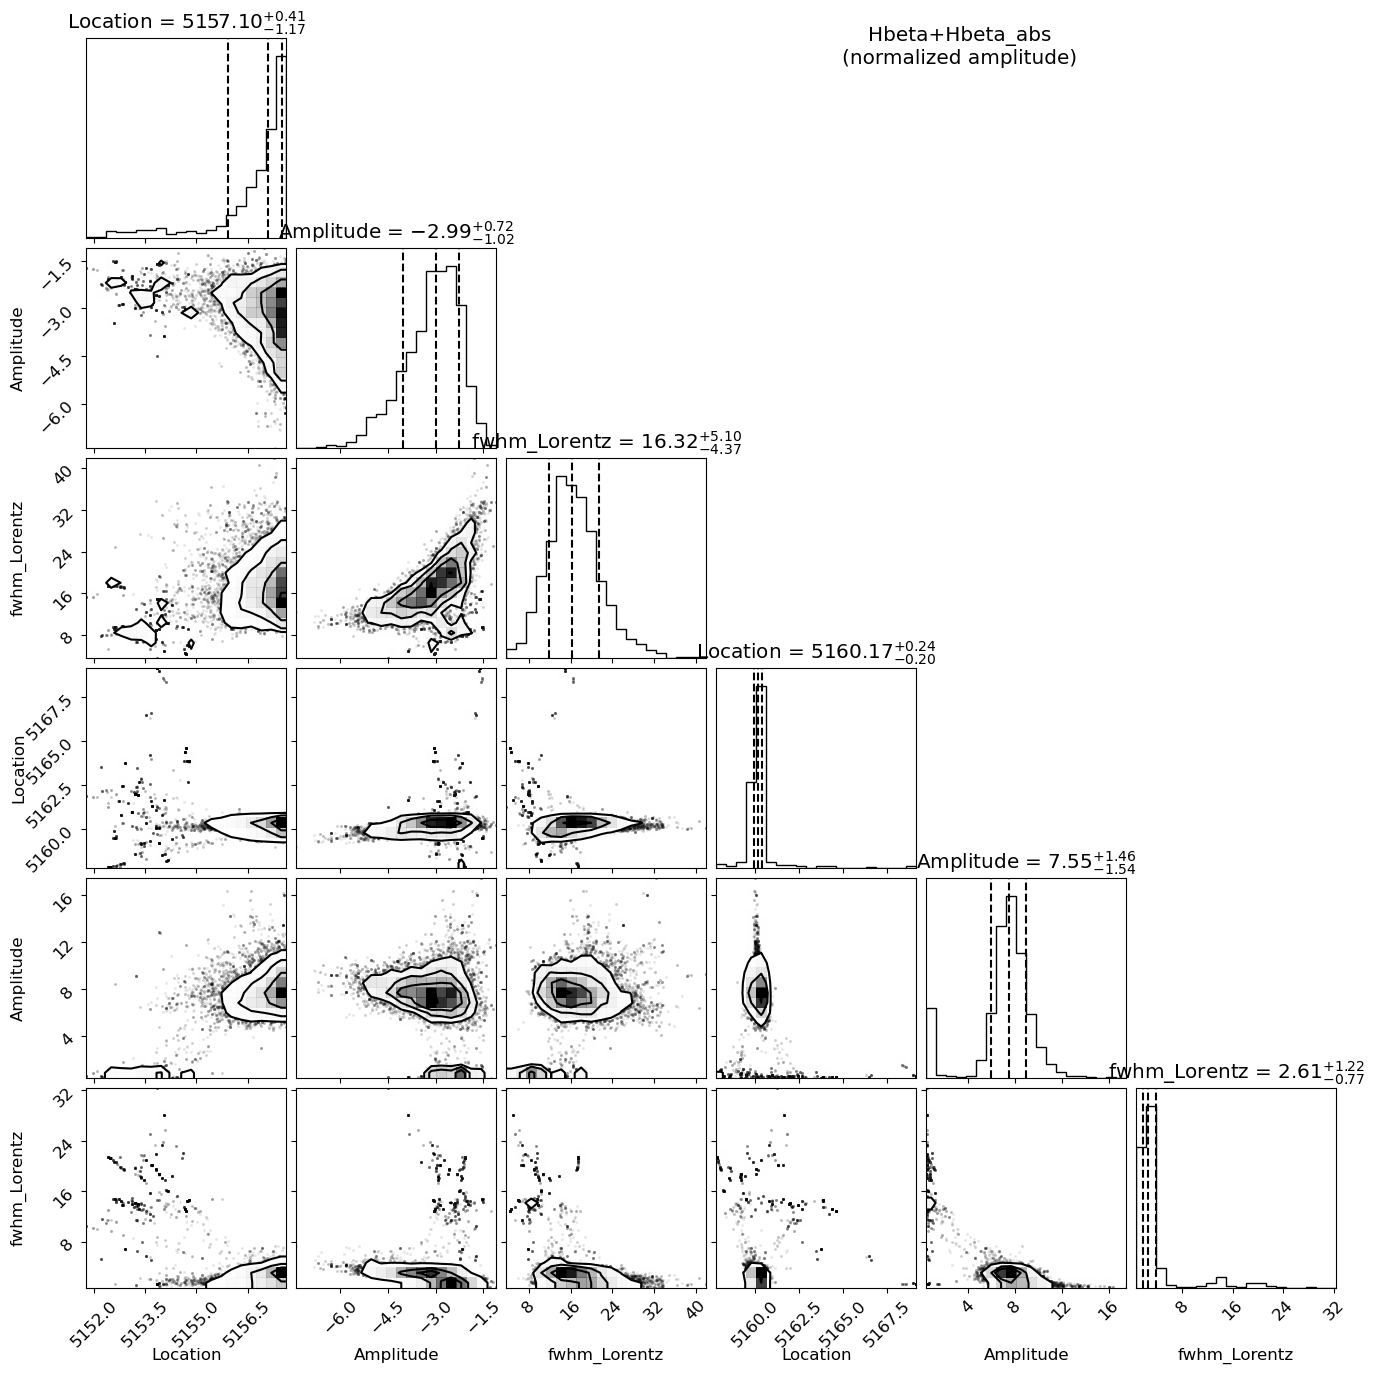

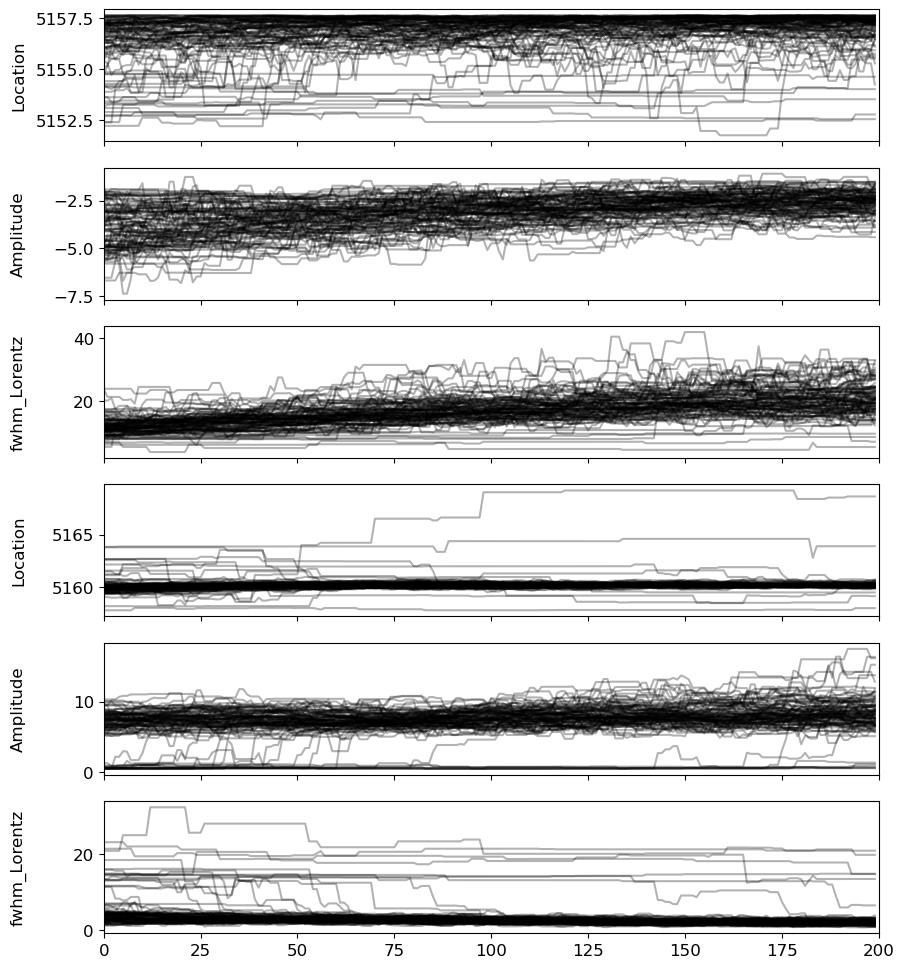

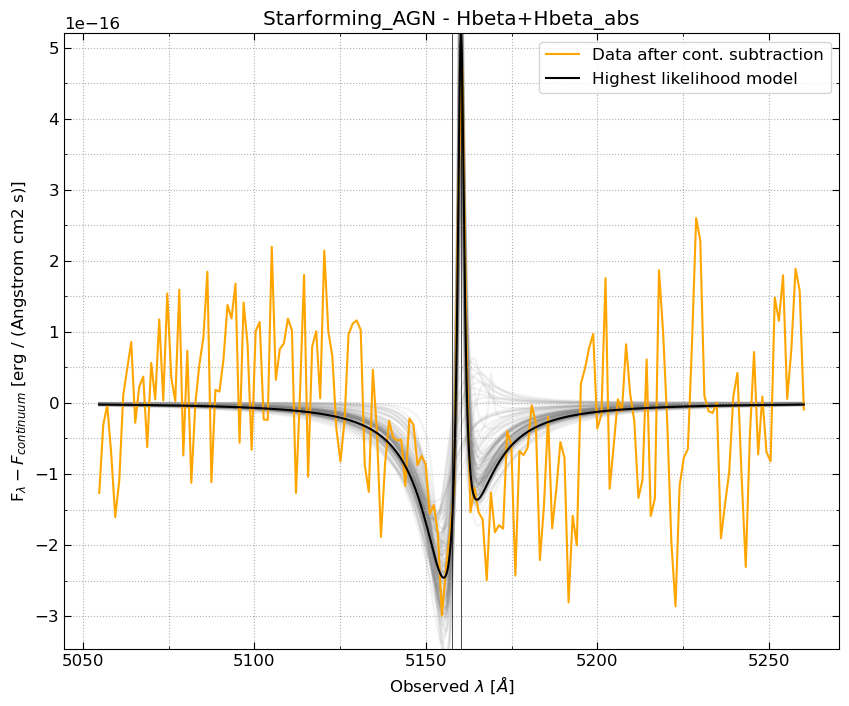

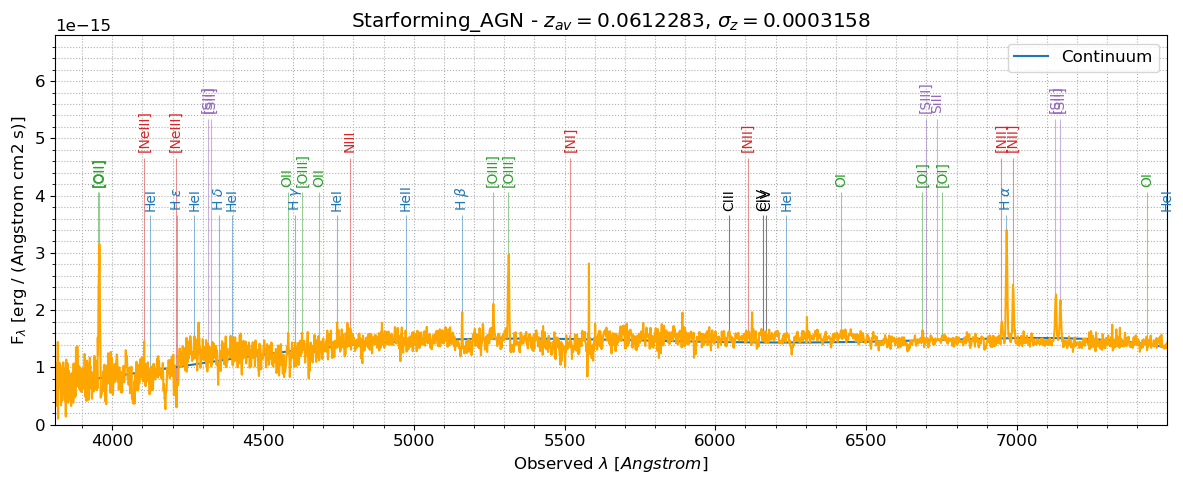

In [6]:
par_values_list , par_values_errors_list ,par_names_list, samples_list, line_windows = analysis.fit_lines(wavelengths,
                    flux_density, continuum_baseline, wavelength_peak_positions_slice, rest_frame_line_wavelengths,
                    peak_heights_slice, line_std_deviation_slice, blended_line_min_separation = 80, which_models=which_models,
                    line_names = line_names, overplot_archival_lines = overplot_archival_lines, priors = priors,
                    MCMC_walkers = 100, MCMC_iterations = 200, MCMC_burn_in=100, MCMC_show_progress=True, plot_spec = True, plot_MCMC = True,
                    overplot_median_model = False, save_results=True)

Notice that **the continuum around the H$\beta$ line is well modeled, that is, the residuals show only random fluctuations around zero**.

We can now use the function `analysis.line_physics()` to compute the properties of the fitted line. Keep in mind that the physically meaningful quantities here are the *modeled* values, not those derived directly from the *profile*:

In [7]:
profile_equiv_width_rest_frame, modeled_equiv_width_rest_frame, profile_integrated_flux, modeled_integrated_flux, profile_rest_frame_disp_velocity, modeled_rest_frame_disp_velocity, profile_line_dispersion_rest_frame, profile_rest_frame_fwhm, modeled_rest_frame_fhwm = analysis.line_physics(wavelengths, flux_density, continuum_baseline, par_values_list, par_values_errors_list, par_names_list, line_windows, line_std_deviation, sistemic_redshift = None, plot = False, save_file = True)

Note that absorption lines have positive equivalent widths, while emission lines have negative equivalent widths:

In [8]:
modeled_equiv_width_rest_frame

<Quantity [[ 2.4197032 ,  0.22843884,  0.16758339],
           [-0.97680161,  0.06547416,  0.06835422]] Angstrom>

Now, the integrated flux of each line component:

In [9]:
modeled_integrated_flux

<Quantity [[-3.83273764e-15,  3.61839267e-16,  2.65445672e-16],
           [ 1.54859714e-15,  1.03801104e-16,  1.08367068e-16]] erg / (cm2 s)>

In [10]:
modeled_rest_frame_disp_velocity

<Quantity [[474.46296696, 126.90093422, 148.26249386],
           [ 75.87857946,  22.25906106,  35.57445174]] km / s>

In [11]:
modeled_rest_frame_fhwm

<Quantity [[15.38640764,  4.11528473,  4.80801959],
           [ 2.46067414,  0.72184135,  1.15364751]] Angstrom>

### What if `easyspec` does not detect the line automatically?

Suppose that **easyspec** fails to identify the absorption component. In that case, you can simply add it manually:

In [12]:
peak_heights_slice = np.asarray([1.3*10**-15,peak_heights[6].value])

Make sure that all elements in the new array share the same units. In this example, we explicitly discard the units by calling `peak_heights[6].value`.

**How should we choose the `peak_height`?**  
A simple approach is to inspect the first plot shown in this tutorial. What is the approximate height of the H$\beta$ absorption component along the y-axis? From a quick visual estimate, it is about $1.3 \times 10^{-15}$.

The remaining input parameters for the function `analysis.fit_lines()` are the same as before:

In [13]:
wavelength_peak_positions_slice = wavelength_peak_positions[[5,6]]
rest_frame_line_wavelengths = [4861,4861]
line_names = ["Hbeta","Hbeta_abs"]
line_std_deviation_slice = line_std_deviation[[5,6]]
which_models= "Lorentzian" 
overplot_archival_lines = ["H","He","O","Ne","C","Si","N","S"]
priors = None

Running burn-in...


100%|████████████████████████████████████████| 100/100 [00:00<00:00, 203.42it/s]


Running production...


100%|████████████████████████████████████████| 200/200 [00:00<00:00, 226.31it/s]


Single-core processing took 1.4 seconds


Archival lines are taken from NIST Atomic Spectra database: https://www.nist.gov/pml/atomic-spectra-database
We adopt vacuum wavelengths for lines with wavelengths < 2000 Angstroms and air wavelengths for lines with wavelengths > 2000 Angstroms.
If you use these lines in your research, please cite the NIST Atomic Spectra database appropriately.


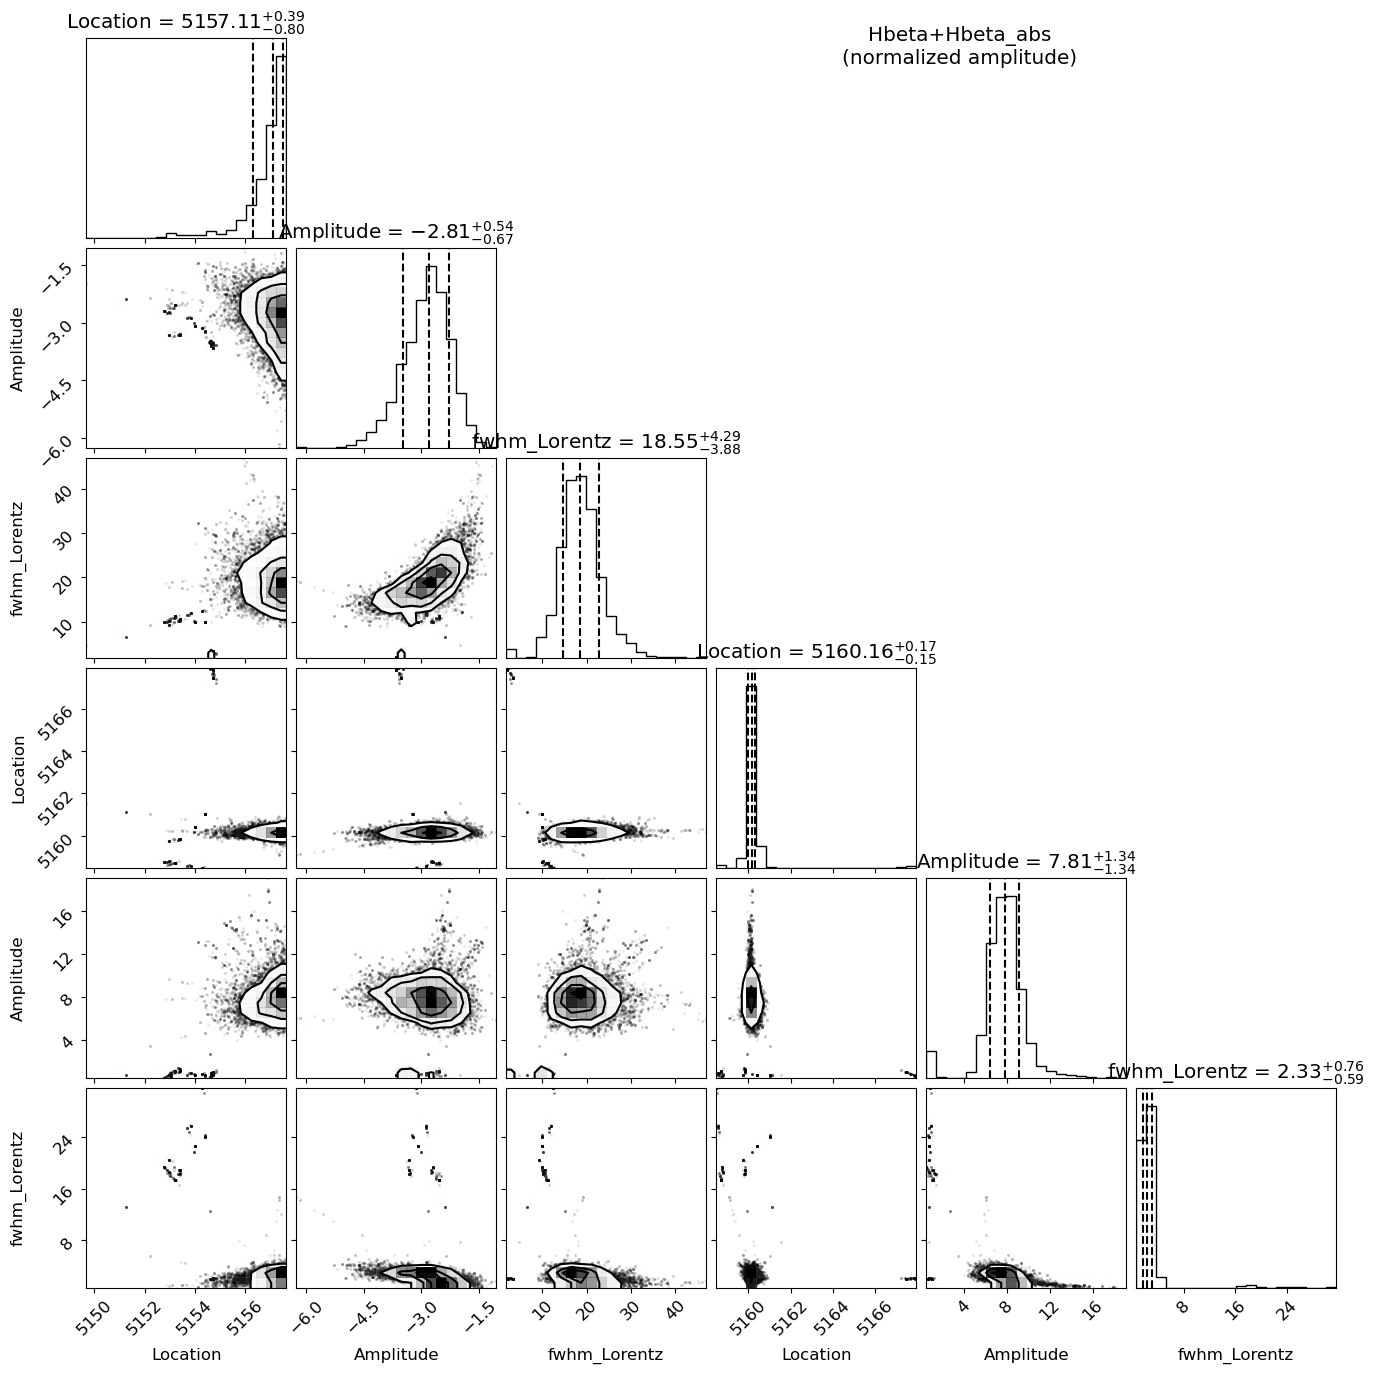

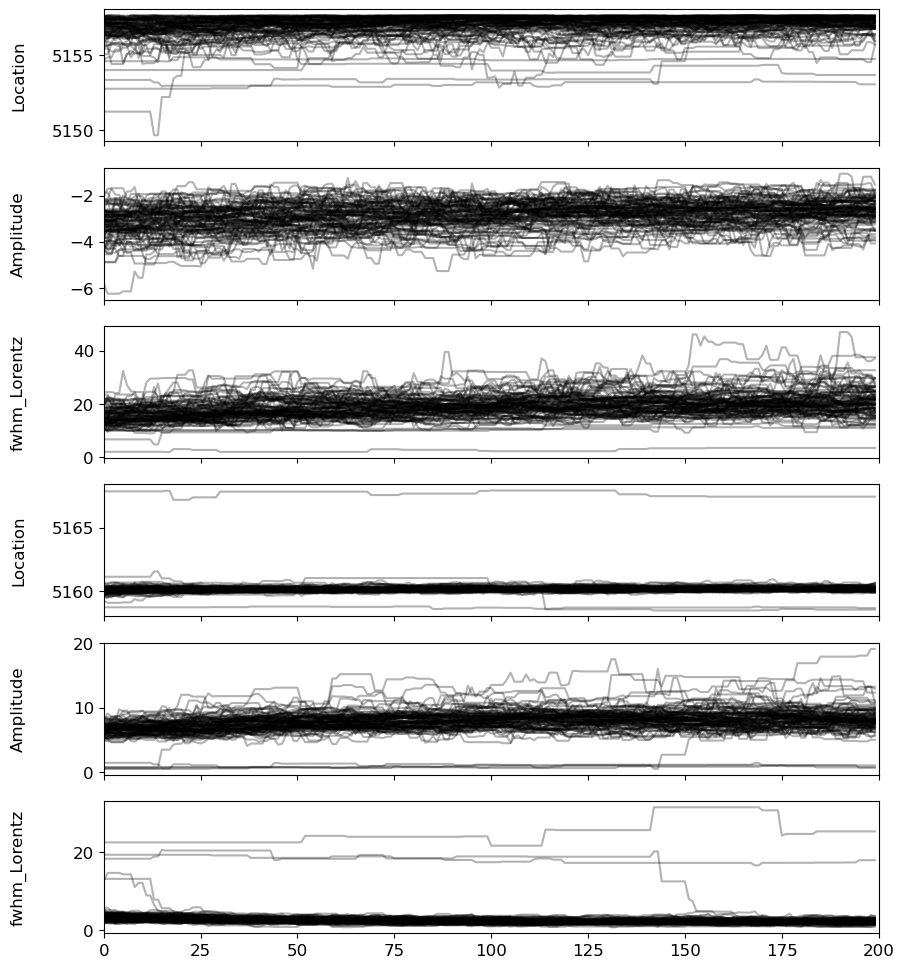

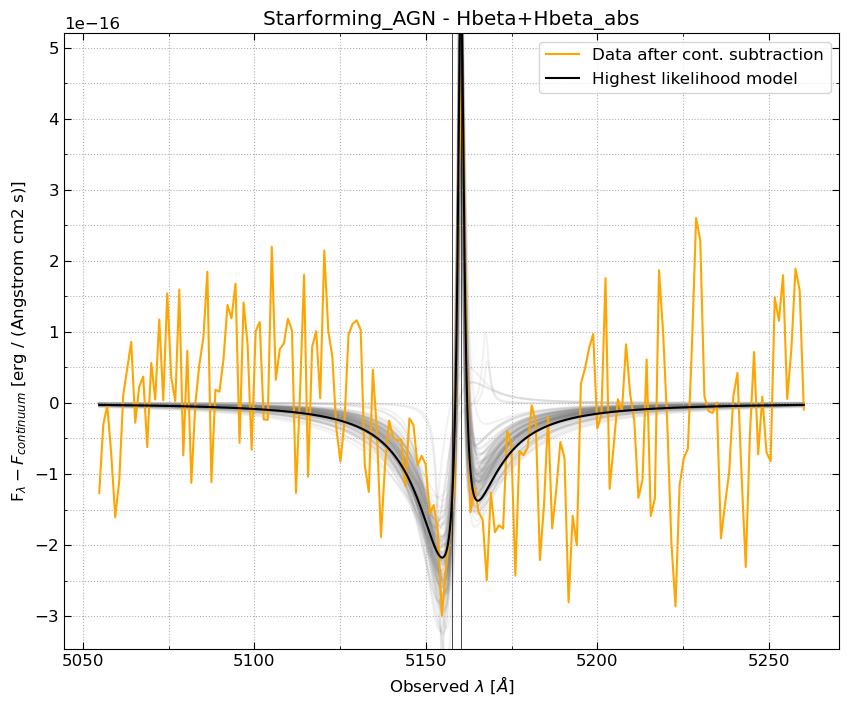

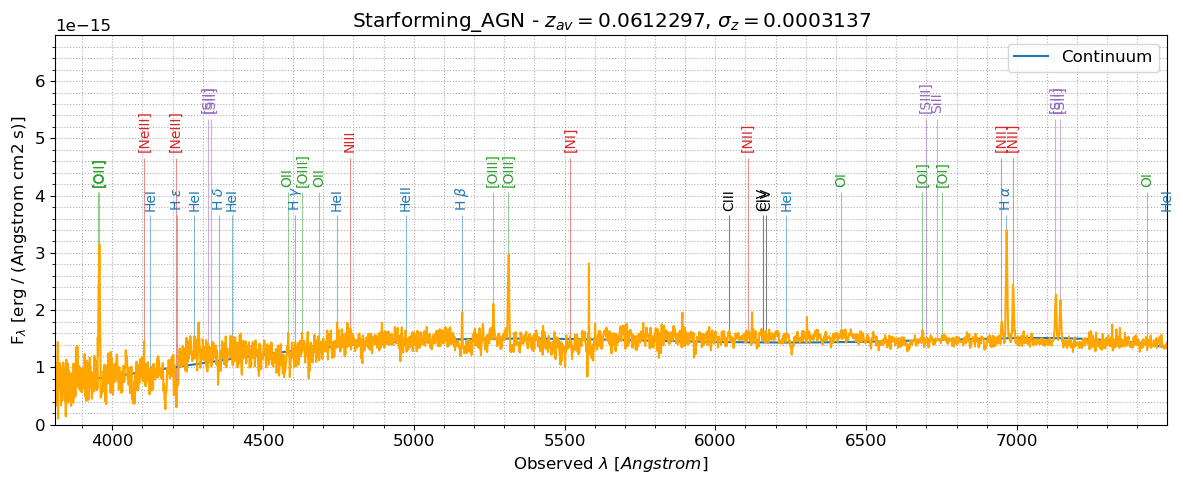

In [14]:
par_values_list , par_values_errors_list ,par_names_list, samples_list, line_windows = analysis.fit_lines(wavelengths,
                    flux_density, continuum_baseline, wavelength_peak_positions_slice, rest_frame_line_wavelengths,
                    peak_heights_slice, line_std_deviation_slice, blended_line_min_separation = 80, which_models=which_models,
                    line_names = line_names, overplot_archival_lines = overplot_archival_lines, priors = priors,
                    MCMC_walkers = 100, MCMC_iterations = 200, MCMC_burn_in=100, MCMC_show_progress=True, plot_spec = True, plot_MCMC = True,
                    overplot_median_model = False, save_results=True)

And this is how we can fit a line with both absorption and emission components.